In [1]:
!nvidia-smi


!pip install -U ultralytics

Mon Sep 21 16:57:52 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
from ultralytics import YOLO
import ultralytics

print("Ultralytics:", ultralytics.__version__)

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Ultralytics: 8.4.157


In [4]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

print(os.listdir("/content/drive/MyDrive"))

In [6]:
!mkdir -p /content/sleeping_person

!unzip -q "/content/drive/MyDrive/Sleeping Person Models With Negatives - yolo26.zip" -d /content/sleeping_person

In [23]:
from pathlib import Path

root = Path("/content/sleeping_person/Sleeping Person Models With Negatives - yolo26")

yaml_files = list(root.rglob("*.yaml")) + list(root.rglob("*.yml"))

for f in yaml_files:
    print(f)

/content/sleeping_person/Sleeping Person Models With Negatives - yolo26/data.yaml


In [24]:
print(Path("/content/sleeping_person/Sleeping Person Models With Negatives - yolo26/data.yaml").read_text())

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 1
names: ['people']

roboflow:
  workspace: smartlight
  project: sleeping-person-models-ver2
  version: 1
  license: CC BY 4.0
  url: https://universe.roboflow.com/smartlight/sleeping-person-models-ver2/dataset/1


In [25]:
from pathlib import Path

for split in ["train", "valid", "test"]:
    image_dir = root / split / "images"
    label_dir = root / split / "labels"

    images = list(image_dir.glob("*")) if image_dir.exists() else []
    labels = list(label_dir.glob("*.txt")) if label_dir.exists() else []

    print(
        f"{split}: "
        f"{len(images)} images, "
        f"{len(labels)} labels"
    )

train: 738 images, 738 labels
valid: 101 images, 101 labels
test: 21 images, 21 labels


In [26]:
label_files = list(
    (root / "train" / "labels").glob("*.txt")
)

print(label_files[0])
print(label_files[0].read_text())

/content/sleeping_person/Sleeping Person Models With Negatives - yolo26/train/labels/IMG_3248_JPG.rf.98529a32de08d28ae5e80c76335ebeca.txt
0 0.5296875 0.484375 0.878125 0.81171875


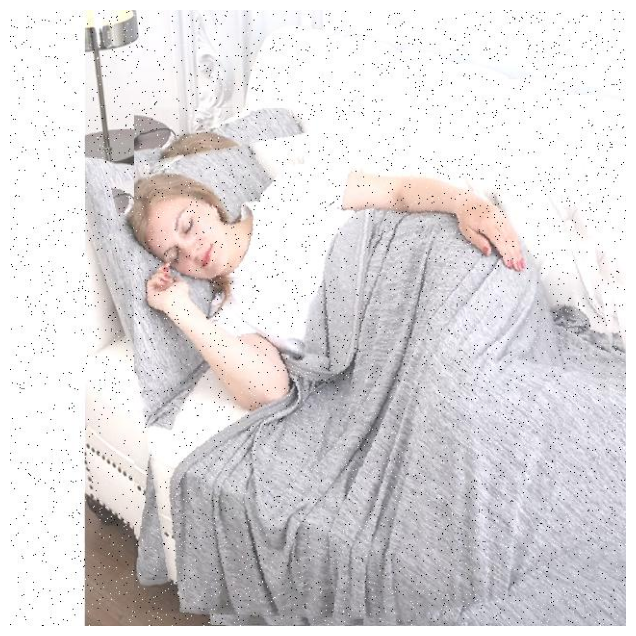

In [27]:
import cv2
import matplotlib.pyplot as plt

image_path = list((root / "train" / "images").glob("*"))[0]

image = cv2.imread(str(image_path))
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 8))
plt.imshow(image)
plt.axis("off");

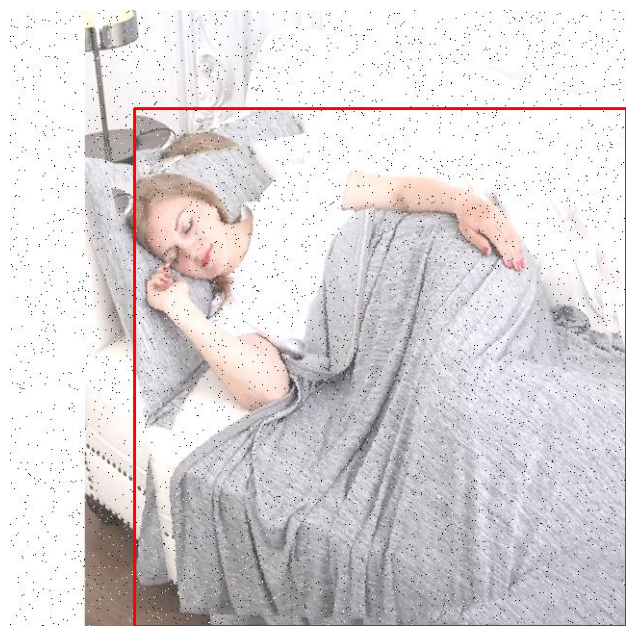

In [28]:
from pathlib import Path

label_path = (
    root /
    "train" /
    "labels" /
    f"{image_path.stem}.txt"
)

h, w = image.shape[:2]

image_box = image.copy()

for line in label_path.read_text().splitlines():

    class_id, cx, cy, bw, bh = map(float, line.split())

    x1 = int((cx - bw / 2) * w)
    y1 = int((cy - bh / 2) * h)
    x2 = int((cx + bw / 2) * w)
    y2 = int((cy + bh / 2) * h)

    cv2.rectangle(
        image_box,
        (x1, y1),
        (x2, y2),
        (255, 0, 0),
        2,
    )

plt.figure(figsize=(8, 8))
plt.imshow(image_box)
plt.axis("off");

In [29]:
model = YOLO("yolo26n.pt")

In [30]:
results = model.train(
    data="/content/sleeping_person/Sleeping Person Models With Negatives - yolo26/data.yaml",

    epochs=100,
    imgsz=640,

    batch=16,

    patience=15,

    device=0,
    workers=2,

    project="/content/runs",
    name="sleeping-person-yolo26n-v2",

    pretrained=True,
)

Ultralytics 8.4.157 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/sleeping_person/Sleeping Person Models With Negatives - yolo26/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0

In [31]:
from pathlib import Path

run_dir = Path(
    "/content/runs/sleeping-person-yolo26n-v2"
)

print(list(run_dir.iterdir()))

[PosixPath('/content/runs/sleeping-person-yolo26n-v2/weights'), PosixPath('/content/runs/sleeping-person-yolo26n-v2/val_batch2_pred.jpg'), PosixPath('/content/runs/sleeping-person-yolo26n-v2/train_batch1.jpg'), PosixPath('/content/runs/sleeping-person-yolo26n-v2/val_batch0_pred.jpg'), PosixPath('/content/runs/sleeping-person-yolo26n-v2/confusion_matrix.png'), PosixPath('/content/runs/sleeping-person-yolo26n-v2/val_batch2_labels.jpg'), PosixPath('/content/runs/sleeping-person-yolo26n-v2/confusion_matrix_normalized.png'), PosixPath('/content/runs/sleeping-person-yolo26n-v2/val_batch1_labels.jpg'), PosixPath('/content/runs/sleeping-person-yolo26n-v2/BoxP_curve.png'), PosixPath('/content/runs/sleeping-person-yolo26n-v2/val_batch0_labels.jpg'), PosixPath('/content/runs/sleeping-person-yolo26n-v2/BoxF1_curve.png'), PosixPath('/content/runs/sleeping-person-yolo26n-v2/args.yaml'), PosixPath('/content/runs/sleeping-person-yolo26n-v2/BoxPR_curve.png'), PosixPath('/content/runs/sleeping-person-yo

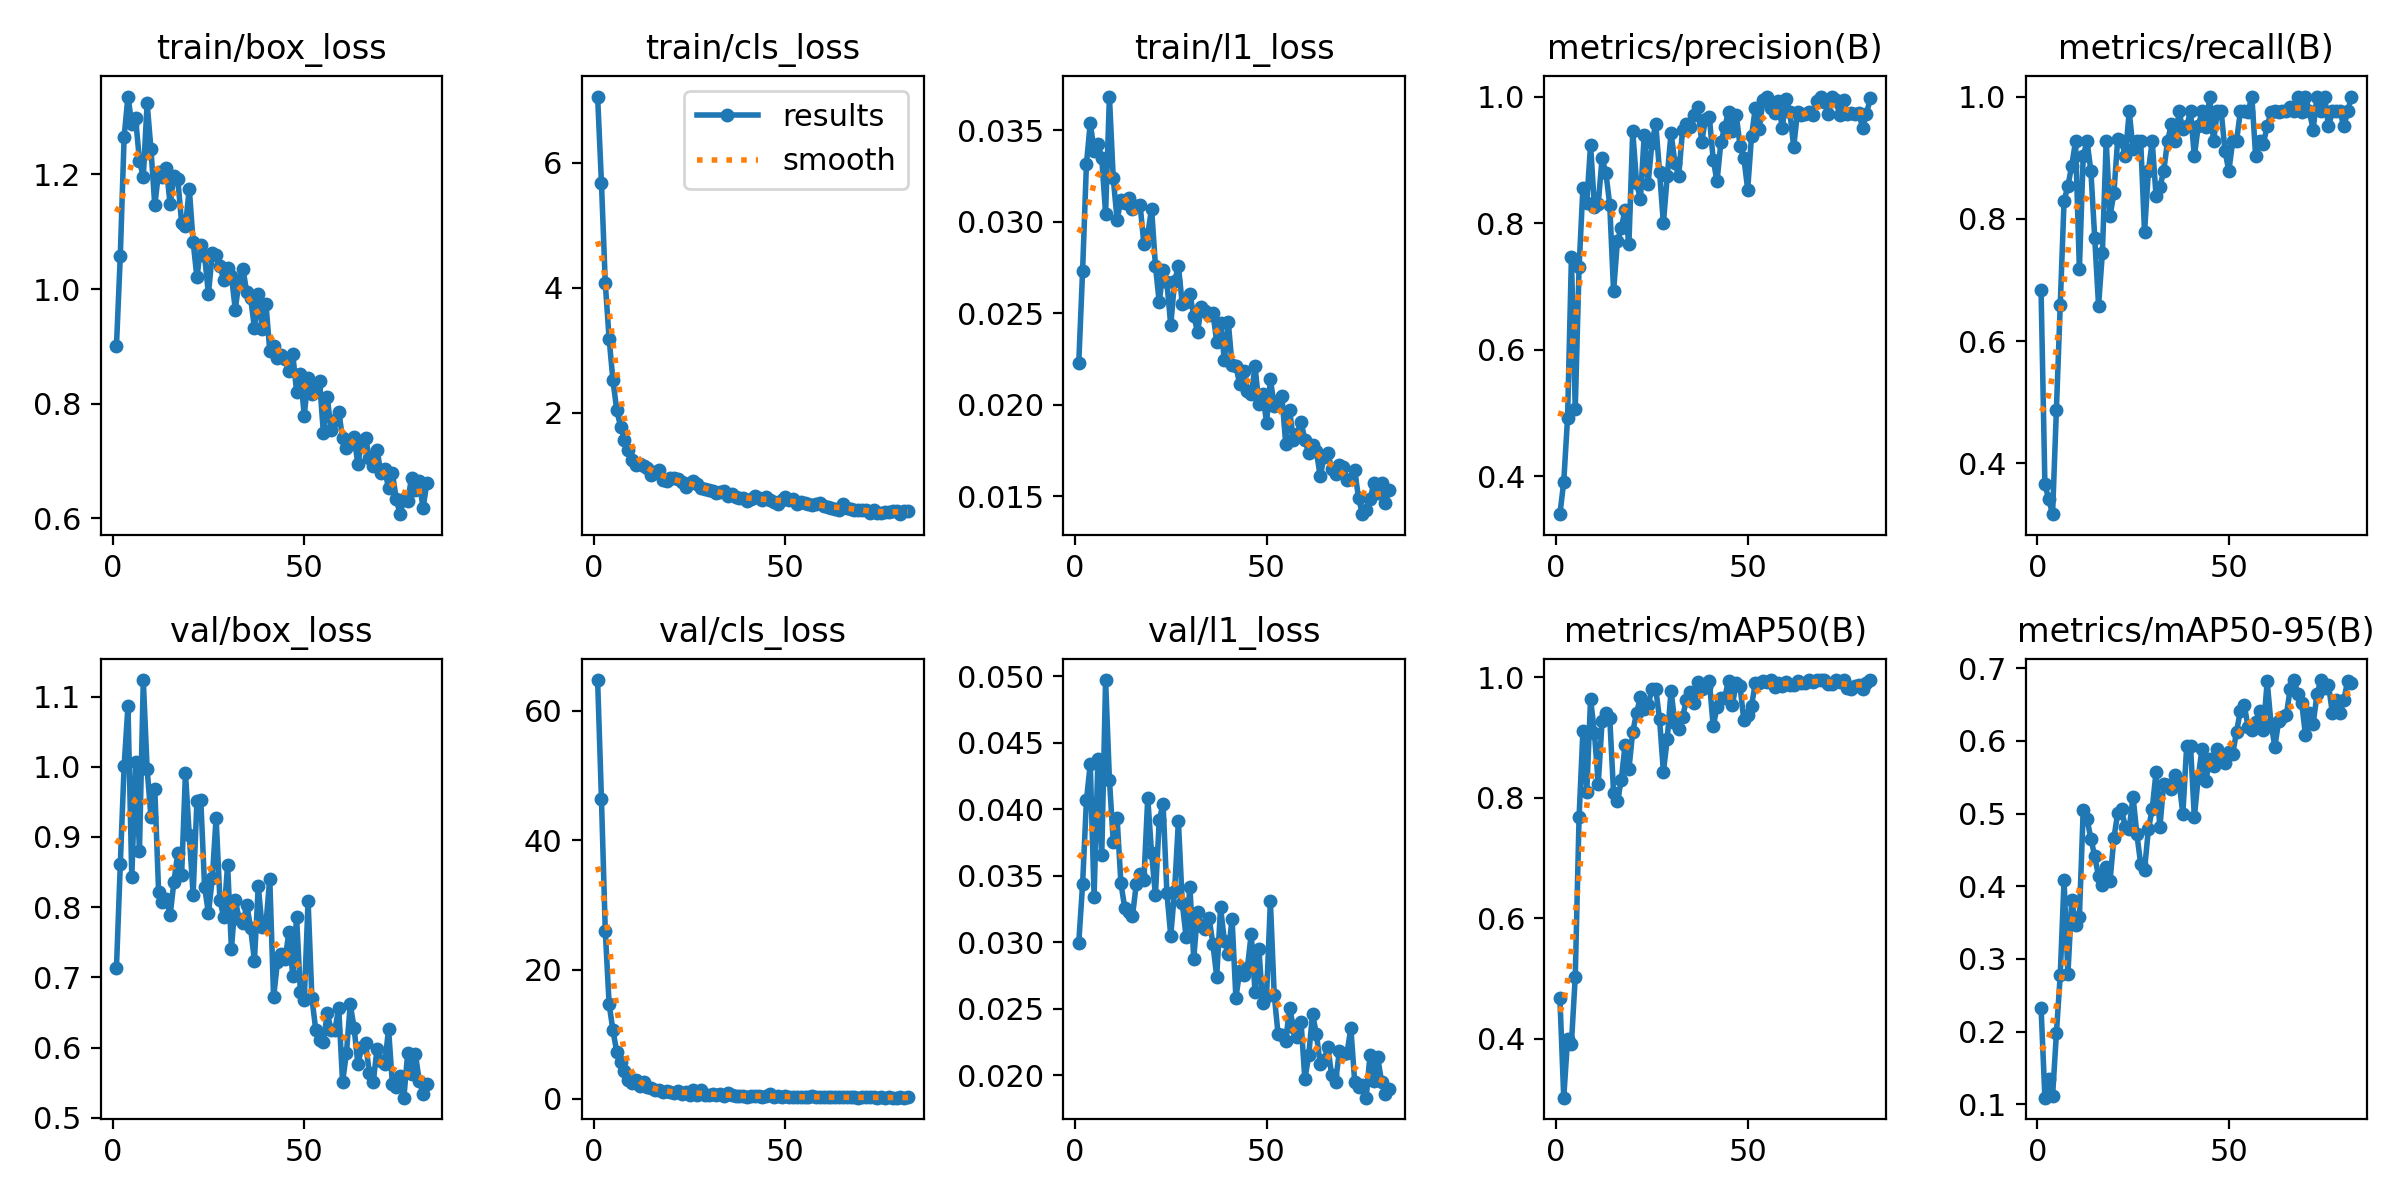

In [32]:
from IPython.display import Image, display

display(
    Image(
        filename="/content/runs/sleeping-person-yolo26n-v2/results.png"
    )
)

In [33]:
best_model = YOLO(
    "/content/runs/sleeping-person-yolo26n-v2/weights/best.pt"
)

test_results = best_model.val(
    data="/content/sleeping_person/Sleeping Person Models With Negatives - yolo26/data.yaml",
    split="test",
    imgsz=640,
    device=0,
)

Ultralytics 8.4.157 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 120 layers, 2,375,031 parameters, 0 gradients, 5.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1162.0±396.1 MB/s, size: 38.3 KB)
val: Scanning /content/sleeping_person/Sleeping Person Models With Negatives - yolo26/test/labels... 21 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 21/21 2.1Kit/s 0.0s
val: New cache created: /content/sleeping_person/Sleeping Person Models With Negatives - yolo26/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 3.6it/s 0.6s0.9s
                   all         21         22      0.953      0.955      0.947      0.673
Speed: 5.1ms preprocess, 12.6ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to /content/runs/detect/val


In [34]:
from ultralytics import YOLO

model = YOLO(
    "/content/runs/sleeping-person-yolo26n-v2/weights/best.pt"
)

model.export(
    format="onnx",
    imgsz=640,
    opset=17,
    simplify=True,
)

Ultralytics 8.4.157 🚀 Python-3.13.15 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino
YOLO26n summary (fused): 120 layers, 2,375,031 parameters, 0 gradients, 5.3 GFLOPs

PyTorch: starting from '/content/runs/sleeping-person-yolo26n-v2/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 5, 8400) (5.1 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxruntime', 'onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.13.15 environment at: /usr
Resolved 12 packages in 283ms
Prepared 5 packages in 520ms
Uninstalled 1 package in 5ms
Installed 5 packages in 36ms
 + colorama==0.4.6
 + onnx==1.23.0
 + onnxruntime==1.30.0
 + onnxslim==0.1.96
 - protobuf==5.29.6
 + protobuf==7.36.2

requirements: AutoUpdate success ✅ 1.2s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to 

'/content/runs/sleeping-person-yolo26n-v2/weights/best.onnx'

In [35]:
from pathlib import Path

onnx_path = Path(
    "/content/runs/sleeping-person-yolo26n-v2/weights/best.onnx"
)

print(onnx_path)
print(f"Size: {onnx_path.stat().st_size / 1024 / 1024:.2f} MB")

/content/runs/sleeping-person-yolo26n-v2/weights/best.onnx
Size: 9.34 MB


In [36]:
!cp /content/runs/sleeping-person-yolo26n-v2/weights/best.onnx /content/drive/MyDrive/sleep_person_yolo26n-v2.onnx

In [37]:
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/sleep_person_yolo26n-v2.onnx")

results = model("/content/drive/MyDrive/test2.jpg", verbose=True)

for result in results:
    print(result.boxes)

Loading /content/drive/MyDrive/sleep_person_yolo26n-v2.onnx for ONNX Runtime inference...
requirements: Ultralytics requirement ['onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.13.15 environment at: /usr
Resolved 5 packages in 201ms
Prepared 1 package in 2.73s
Installed 1 package in 36ms
 + onnxruntime-gpu==1.30.0

requirements: AutoUpdate success ✅ 3.1s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

Using ONNX Runtime 1.30.0 with CPUExecutionProvider
WARNING ⚠️ CUDA requested but CUDAExecutionProvider not available. Using CPU...

image 1/1 /content/drive/MyDrive/test2.jpg: 640x640 (no detections), 85.5ms
Speed: 5.3ms preprocess, 85.5ms inference, 4.3ms postprocess per image at shape (1, 3, 640, 640)
ultralytics.engine.results.Boxes object with attributes:

cls: tensor([])
conf: tensor([])
data: tensor([], size=(0, 6))
id: None
is_track: False
orig_shape: (800, 1400)
shape: torch.Size([0, 6])
xywh: tensor([], size=(0, 4))
xyw

In [38]:
results = model("/content/drive/MyDrive/test.jpg", verbose=True)

for result in results:
    print(result.boxes)


image 1/1 /content/drive/MyDrive/test.jpg: 640x640 2 peoples, 88.6ms
Speed: 4.0ms preprocess, 88.6ms inference, 21.4ms postprocess per image at shape (1, 3, 640, 640)
ultralytics.engine.results.Boxes object with attributes:

cls: tensor([0., 0.])
conf: tensor([0.6999, 0.5867])
data: tensor([[3.2031e-01, 1.2618e+02, 2.7995e+02, 5.9318e+02, 6.9995e-01, 0.0000e+00],
        [2.8736e+02, 1.2268e+02, 5.7792e+02, 6.1861e+02, 5.8670e-01, 0.0000e+00]])
id: None
is_track: False
orig_shape: (640, 640)
shape: torch.Size([2, 6])
xywh: tensor([[140.1367, 359.6803, 279.6328, 467.0006],
        [432.6367, 370.6462, 290.5574, 495.9310]])
xywhn: tensor([[0.2190, 0.5620, 0.4369, 0.7297],
        [0.6760, 0.5791, 0.4540, 0.7749]])
xyxy: tensor([[3.2031e-01, 1.2618e+02, 2.7995e+02, 5.9318e+02],
        [2.8736e+02, 1.2268e+02, 5.7792e+02, 6.1861e+02]])
xyxyn: tensor([[5.0049e-04, 1.9716e-01, 4.3743e-01, 9.2684e-01],
        [4.4900e-01, 1.9169e-01, 9.0299e-01, 9.6658e-01]])
